# 05. FILIP ECG Post-Hoc Lead ROI Masking & Register Bias Subtraction (No Retraining)

This notebook demonstrates **Option A Post-Hoc Remediation** to eliminate blank background hotspots during visualization and inference **without retraining any model weights**:
1. **Configurable Target Sample**: Pick specific study IDs (e.g. `03579_hr` / `03579`).
2. **Ground Truth Labels Display**: Displays all ground truth diagnosis codes and full clinical descriptions.
3. **ECG Lead ROI Masking**: Restricts text-patch similarity evaluation exclusively to patches within the 12-lead signal plotting area.
4. **Register Bias Subtraction**: Subtracts generic domain-neutral background similarity ($	ext{Sim}_{\text{disease}} - \text{Sim}_{\text{normal}}$) to isolate true local lead contrast.
5. **Warm Red vs. Transparent Overlay**: Renders clean heatmaps overlayed on top of the original ECG waveform image.

In [1]:
import os
import sys
import random
import importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from transformers import CLIPTokenizer

# Ensure project root (containing the 'filip' package) is in sys.path
current_dir = os.path.abspath(os.getcwd())
if os.path.basename(current_dir) == 'visualization':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..', '..'))
elif os.path.basename(current_dir) == 'filip':
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = current_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root resolved to: {PROJECT_ROOT}")

# Reload diagnostic_utils to prevent stale Jupyter kernel sys.modules cache
if 'filip.visualization.diagnostic_utils' in sys.modules:
    importlib.reload(sys.modules['filip.visualization.diagnostic_utils'])

from filip.visualization.diagnostic_utils import (
    ExpandToSquare,
    get_exact_training_transform,
    load_model_from_checkpoint,
    compute_token_patch_similarity,
    compute_phrase_level_patch_similarity,
    create_ecg_lead_roi_mask,
    apply_roi_mask_to_similarity,
    compute_bias_subtracted_patch_similarity,
    get_warm_red_transparent_cmap
)
from filip.data.dataset import ECGImageDataset

SUBCLASS_DESCRIPTIONS = {
    'AMI': 'anterior myocardial infarction',
    'ALMI': 'anterolateral myocardial infarction',
    'ASMI': 'anteroseptal myocardial infarction',
    'ILMI': 'inferolateral myocardial infarction',
    'IMI': 'inferior myocardial infarction',
    'SEHYP': 'septal hypertrophy',
    'CRBBB': 'complete right bundle branch block',
    'WPW': 'Wolff-Parkinson-White syndrome',
    'LAO/LAE': 'left atrial overload or enlargement',
    'NORM': 'normal sinus rhythm',
    'ISC': 'ischemic ST-T changes',
    'AVB': 'atrioventricular block',
    'RAO/RAE': 'right atrial overload or enlargement',
    'LMI': 'lateral myocardial infarction',
    'ISCI': 'ischemic infarction',
    'ISCA': 'ischemic anterior changes',
    'NST': 'non-specific ST-T changes',
    'CLBBB': 'complete left bundle branch block',
    'ILBBB': 'incomplete left bundle branch block',
    'IRBBB': 'incomplete right bundle branch block',
    'PMI': 'posterior myocardial infarction',
    'RVH': 'right ventricular hypertrophy',
    'IVCD': 'intraventricular conduction delay'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using remediation execution device: {device}")
warm_red_cmap = get_warm_red_transparent_cmap()

/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/qfbqt/miniconda3/envs/gem/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root resolved to: /home/qfbqt/repo/GEM-fork
Using remediation execution device: cuda


## 1. Load Checkpoint, Pick Target Sample (`03579_hr`) & Prepare Lead ROI Mask

Initialized standard CLIPVisionModel from openai/clip-vit-large-patch14 with image_size=224, patch_size=14
SELECTED TARGET SAMPLE INDEX : 445 / 2158
SELECTED STUDY ID            : 03579_hr
RAW IMAGE SIZE (W x H)       : 2200 x 1700
GROUND TRUTH DIAGNOSES CODES : ['IMI']
GROUND TRUTH DESCRIPTIONS    : ['inferior myocardial infarction']


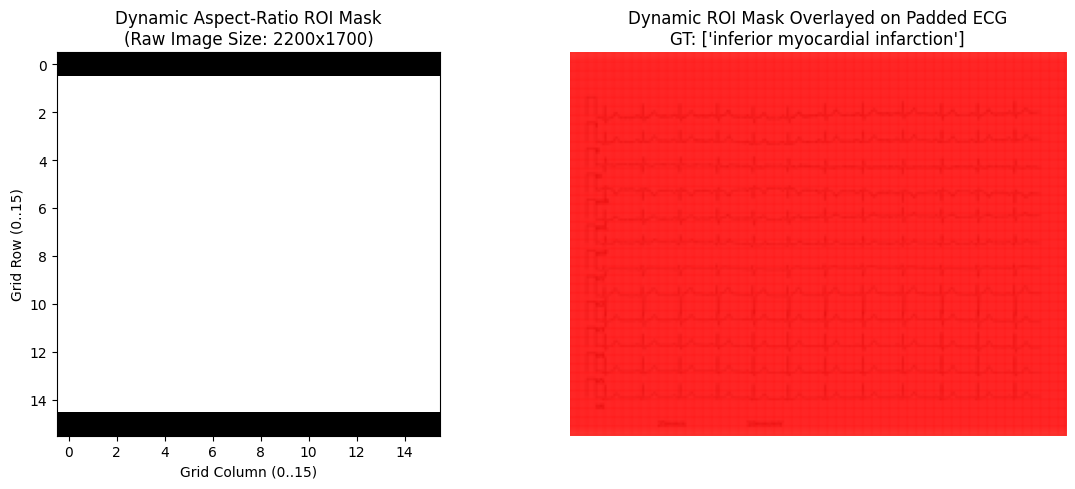

In [2]:
from filip.visualization.diagnostic_utils import (
    get_padding_info, map_patch_to_raw_pixels, plot_warm_red_overlay,
    ExpandToSquare, get_exact_training_transform, load_model_from_checkpoint,
    compute_token_patch_similarity, compute_phrase_level_patch_similarity,
    create_ecg_lead_roi_mask, apply_roi_mask_to_similarity,
    compute_bias_subtracted_patch_similarity, get_warm_red_transparent_cmap
)
from filip.data.dataset import ECGImageDataset

TARGET_STUDY_ID = "03579_hr"

ckpt_stg2_paths = [
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'vit_large_ptbxl_sub_report_align_adapt_100', 'best.pt'),
    os.path.join(PROJECT_ROOT, 'outputs', 'filip', 'ptbxl_sub_report_align_adapt_100', 'best.pt')
]
ckpt_stg2 = next((p for p in ckpt_stg2_paths if os.path.exists(p)), None)

model_stg2, config = load_model_from_checkpoint(ckpt_stg2, device=device)
tokenizer = CLIPTokenizer.from_pretrained(config.get('model', {}).get('text_encoder', 'openai/clip-vit-large-patch14'))

image_size = config.get('model', {}).get('image_size', 224)
patch_size = config.get('model', {}).get('patch_size', 14)
grid_size = image_size // patch_size
data_root = os.path.join(PROJECT_ROOT, config.get('data_root', 'data/ptbxl_sub_class/'))
if not os.path.exists(data_root):
    data_root = os.path.join(PROJECT_ROOT, 'data', 'ptbxl_sub_class')

dataset_name = config.get('dataset_name', 'ptbxl_sub')
transform = get_exact_training_transform(image_size=image_size)
test_dataset = ECGImageDataset(data_root=data_root, split='test', dataset_name=dataset_name, transform=transform)

selected_idx = None
if TARGET_STUDY_ID.strip():
    target_clean = TARGET_STUDY_ID.strip().lower()
    for idx, record in enumerate(test_dataset.records):
        rec_id = str(record.get('study_id', record.get('ecg_id', ''))).lower()
        if rec_id == target_clean or f"{rec_id}_hr" == target_clean or target_clean.startswith(rec_id):
            selected_idx = idx
            break
    if selected_idx is None:
        print(f"Study ID '{TARGET_STUDY_ID}' not found in test split. Defaulting to index 0.")
        selected_idx = 0
else:
    selected_idx = 0

sample = test_dataset[selected_idx]
image_tensor = sample['images'].unsqueeze(0).to(device)
study_id = sample['sample_ids']

raw_img_path = os.path.join(data_root, 'images', f"{study_id}-0.png")
if not os.path.exists(raw_img_path):
    raw_img_path = os.path.join(data_root, f"{study_id}-0.png")
raw_image = Image.open(raw_img_path).convert('RGB') if os.path.exists(raw_img_path) else Image.new('RGB', (image_size, image_size), (255, 255, 255))
padded_square = ExpandToSquare(background_color=(255, 255, 255))(raw_image).resize((image_size, image_size))

gt_labels = []
gt_full_descriptions = []
if 'diagnosis_targets' in sample and sample['diagnosis_targets'] is not None:
    targets = sample['diagnosis_targets']
    for i, target_val in enumerate(targets):
        if target_val > 0.5 and i < len(test_dataset.diagnosis_list):
            diag_code = test_dataset.diagnosis_list[i]
            gt_labels.append(diag_code)
            gt_full_descriptions.append(SUBCLASS_DESCRIPTIONS.get(diag_code, diag_code))

print("=" * 75)
print(f"SELECTED TARGET SAMPLE INDEX : {selected_idx} / {len(test_dataset)}")
print(f"SELECTED STUDY ID            : {study_id}")
print(f"RAW IMAGE SIZE (W x H)       : {raw_image.size[0]} x {raw_image.size[1]}")
print(f"GROUND TRUTH DIAGNOSES CODES : {gt_labels if gt_labels else ['NORM']}")
print(f"GROUND TRUTH DESCRIPTIONS    : {gt_full_descriptions if gt_full_descriptions else ['normal sinus rhythm']}")
print("=" * 75)

roi_mask = create_ecg_lead_roi_mask(image_size=image_size, patch_size=patch_size, raw_shape=raw_image.size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(roi_mask, cmap='binary_r')
axes[0].set_title(f"Dynamic Aspect-Ratio ROI Mask\n(Raw Image Size: {raw_image.size[0]}x{raw_image.size[1]})")
axes[0].set_xlabel("Grid Column (0..15)")
axes[0].set_ylabel("Grid Row (0..15)")

plot_warm_red_overlay(axes[1], padded_square, roi_mask.astype(float), vmin=0, vmax=1, raw_shape=raw_image.size)
axes[1].set_title(f"Dynamic ROI Mask Overlayed on Padded ECG\nGT: {gt_full_descriptions}")
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 2. Before vs. After ROI Lead Masking (Warm Red Overlay Comparison)

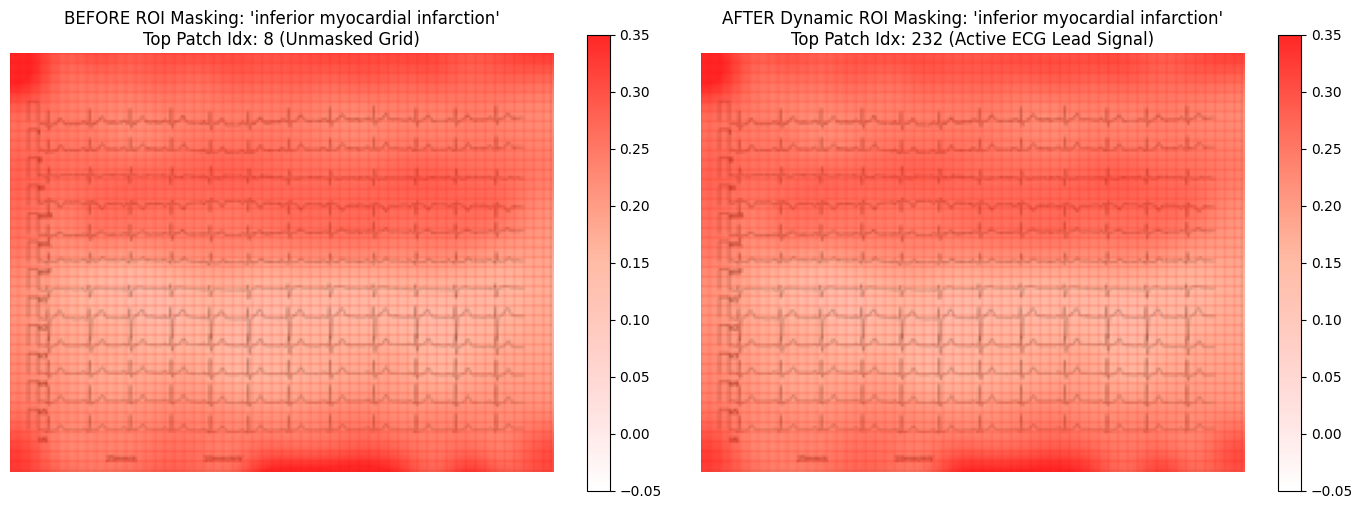

In [3]:
phrases = gt_full_descriptions if gt_full_descriptions else ['myocardial infarction', 'left ventricular hypertrophy']

for phrase in phrases:
    phrase_sim = compute_phrase_level_patch_similarity(model_stg2, tokenizer, image_tensor, phrase, pooling='mean', device=device)
    raw_sim = phrase_sim['similarity_map'].reshape(grid_size, grid_size)
    
    masked_sim = apply_roi_mask_to_similarity(raw_sim, roi_mask, fill_value=np.min(raw_sim))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    im0_overlay = plot_warm_red_overlay(axes[0], padded_square, raw_sim, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[0].set_title(f"BEFORE ROI Masking: '{phrase}'\nTop Patch Idx: {np.argmax(raw_sim)} (Unmasked Grid)")
    fig.colorbar(im0_overlay, ax=axes[0])
    
    im1_overlay = plot_warm_red_overlay(axes[1], padded_square, masked_sim, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
    axes[1].set_title(f"AFTER Dynamic ROI Masking: '{phrase}'\nTop Patch Idx: {np.argmax(masked_sim)} (Active ECG Lead Signal)")
    fig.colorbar(im1_overlay, ax=axes[1])
    
    plt.tight_layout()
    plt.show()


## 3. Register Bias Subtraction ($\text{Sim}_{\text{query}} - \text{Sim}_{\text{baseline}}$)

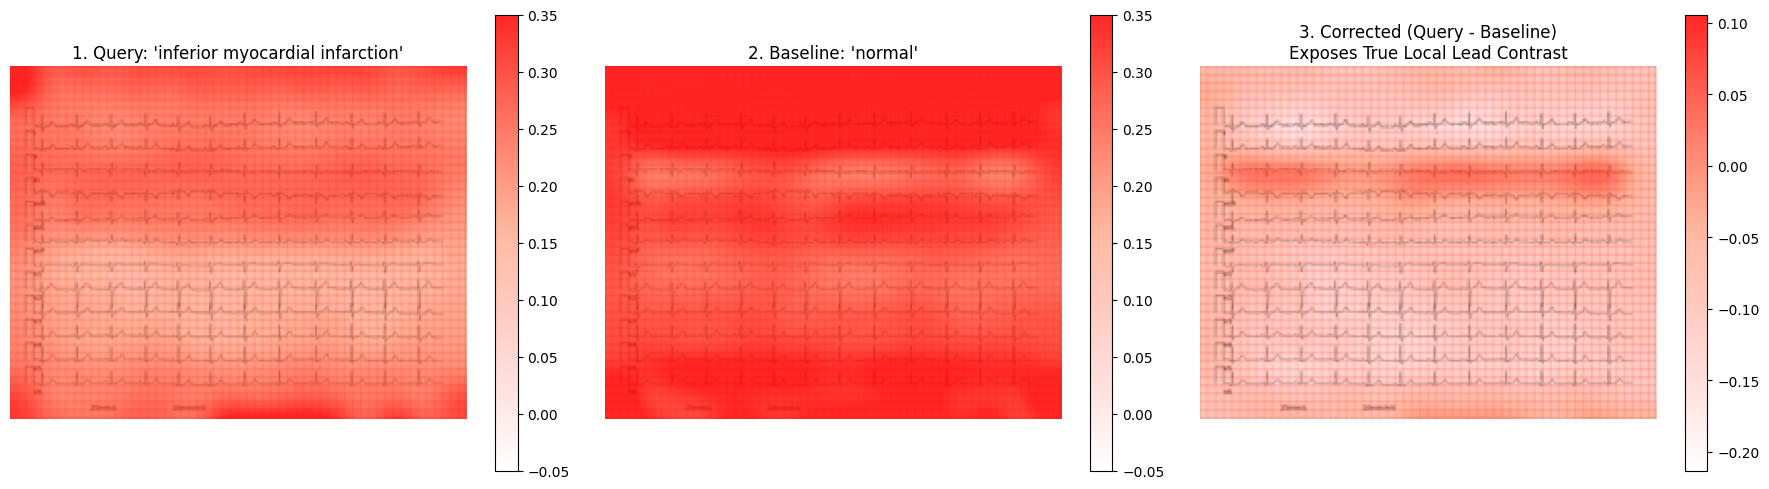

In [4]:
query_phr = gt_full_descriptions[0] if gt_full_descriptions else 'myocardial infarction'
bias_res = compute_bias_subtracted_patch_similarity(
    model_stg2, tokenizer, image_tensor,
    query_phrase=query_phr,
    baseline_phrase='normal',
    lambda_sub=1.0,
    device=device
)

q_map = bias_res['raw_similarity_map'].reshape(grid_size, grid_size)
b_map = bias_res['baseline_similarity_map'].reshape(grid_size, grid_size)
corr_map = bias_res['corrected_similarity_map'].reshape(grid_size, grid_size)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = plot_warm_red_overlay(axes[0], padded_square, q_map, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
axes[0].set_title(f"1. Query: '{query_phr}'")
fig.colorbar(im0, ax=axes[0])

im1 = plot_warm_red_overlay(axes[1], padded_square, b_map, vmin=-0.05, vmax=0.35, raw_shape=raw_image.size)
axes[1].set_title("2. Baseline: 'normal'")
fig.colorbar(im1, ax=axes[1])

im2 = plot_warm_red_overlay(axes[2], padded_square, corr_map, vmin=corr_map.min(), vmax=corr_map.max(), raw_shape=raw_image.size)
axes[2].set_title("3. Corrected (Query - Baseline)\nExposes True Local Lead Contrast")
fig.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


## 4. Quantitative Evaluation Summary (Raw vs. ROI-Remediated Top Patches)

In [5]:
print("=" * 75)
print(f"    POST-HOC DYNAMIC LEAD ROI REMEDIATION QUANTITATIVE SUMMARY (Sample: {study_id})")
print(f"    Raw Image Aspect Dimensions: {raw_image.size[0]} x {raw_image.size[1]}")
print("=" * 75)

terms = gt_full_descriptions if gt_full_descriptions else ['myocardial infarction', 'left ventricular hypertrophy']
for term in terms:
    phrase_sim = compute_phrase_level_patch_similarity(model_stg2, tokenizer, image_tensor, term, device=device)
    raw_map = phrase_sim['similarity_map']
    raw_top_idx = int(np.argmax(raw_map))
    
    masked_map = apply_roi_mask_to_similarity(raw_map, roi_mask, fill_value=-999.0)
    roi_top_idx = int(np.argmax(masked_map))
    
    roi_row = roi_top_idx // grid_size
    roi_col = roi_top_idx % grid_size
    
    pixel_mapping = map_patch_to_raw_pixels(roi_row, roi_col, raw_image.size, image_size=image_size, patch_size=patch_size)
    
    print(f"Phrase: '{term}'")
    print(f"  - Raw Top Patch Index (Unmasked) : {raw_top_idx} (Background Region)")
    print(f"  - Dynamic ROI Top Patch Index    : {roi_top_idx} [Grid Row {roi_row}, Col {roi_col}] (Lead Signal Region)")
    print(f"  - Raw Pixel Bounding Coordinates : X:[{pixel_mapping['x_min']:.1f}..{pixel_mapping['x_max']:.1f}], Y:[{pixel_mapping['y_min']:.1f}..{pixel_mapping['y_max']:.1f}]")
    print(f"  - Signal Region Peak Similarity  : {masked_map[roi_top_idx]:.4f}")
    print("-" * 75)


    POST-HOC DYNAMIC LEAD ROI REMEDIATION QUANTITATIVE SUMMARY (Sample: 03579_hr)
    Raw Image Aspect Dimensions: 2200 x 1700
Phrase: 'inferior myocardial infarction'
  - Raw Top Patch Index (Unmasked) : 8 (Background Region)
  - Dynamic ROI Top Patch Index    : 232 [Grid Row 14, Col 8] (Lead Signal Region)
  - Raw Pixel Bounding Coordinates : X:[1100.0..1237.5], Y:[1675.0..1700.0]
  - Signal Region Peak Similarity  : 0.4424
---------------------------------------------------------------------------
